# PSA Preprocessing and EDA

This notebook loads `seed10.csv`, preprocesses the PSA simulation data, runs EDA for the requested input/output variables, and saves the cleaned result to `output.csv`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [5]:
base_dir = Path(r'C:\Users\junhyun111\Desktop\mf')
data_path = base_dir / 'data.csv'
output_path = base_dir / 'model' / 'output.csv'

df = pd.read_csv(data_path)
print(f'Loaded: {data_path}')
print(f'Shape: {df.shape}')
display(df.head())

Loaded: C:\Users\junhyun111\Desktop\mf\data.csv
Shape: (200, 35)


,Unnamed: 0,sample_id,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail,valid_physics,status_detail,n_cycles,status
0,0,1,121.2316,0.2423,0.0118,64.8647,38.0086,27.9062,0.9887,7.9748,0.0793,0.1830,0.8170,0.8404,0.8957,0.9452,1.0589,0.5228,0.1639,0.6379,0.0469,0.2094,0.0299,0.1526,11.2558,0.1496,11.4607,0.7990,0.2010,0.2049,0.0515,True,ok,10,ok
1,1,2,163.8069,0.3384,0.0286,59.6933,65.9540,9.6816,0.8841,6.0191,0.0871,0.2356,0.7644,0.8666,0.9131,0.9520,1.0564,0.4160,0.4905,0.6927,0.1983,0.6436,0.1374,0.1427,7.0307,0.1294,7.1476,0.6962,0.3038,0.1169,0.0510,True,ok,10,ok
2,2,3,82.4720,0.2309,0.0221,50.1682,40.9718,43.9300,0.1383,2.1531,0.0492,0.1979,0.8021,0.8944,0.9384,0.9685,1.0347,0.3555,0.2280,0.6901,0.0648,0.2624,0.0447,0.1514,12.0743,0.1469,12.2633,0.7893,0.2107,0.1891,0.0505,True,ok,10,ok
3,3,4,96.3668,0.1627,0.0211,53.2543,26.8107,57.5443,0.7232,7.3361,0.0480,0.2499,0.7501,0.8478,0.9018,0.9527,1.0451,0.5145,0.3179,0.7227,0.0914,0.2743,0.0661,0.1418,14.9887,0.1402,15.1518,0.7810,0.2190,0.1631,0.0457,True,ok,10,ok
4,4,5,113.6140,0.1801,0.0315,20.3417,60.8850,44.6156,0.0201,9.7885,0.0337,0.2159,0.7841,0.8832,0.9322,0.9737,1.0430,0.4075,0.3891,0.7082,0.1390,0.5049,0.0985,0.1546,13.5221,0.1476,13.6359,0.7006,0.2994,0.1138,0.0486,True,ok,10,ok


In [6]:
# User-requested names are interpreted against the actual CSV columns.
# h20_ppmv -> h2o_ppmv, s0x_ppmv -> sox_ppmv
input_cols = [
    'tADS', 'PL', 'v0', 't_press', 't_depress',
    'h2o_ppmv', 'sox_ppmv', 'nox_ppmv', 'dust_mg_Nm3',
    'co2_mol_frac', 'n2_mol_frac_effective',
    'capacity_factor', 'affinity_factor_co2', 'mtc_factor',
    'dax_factor', 'deactivation_index'
]

target_cols = ['CO2_purity', 'CO2_recovery']

helper_cols = [
    'sample_id', 'valid_physics', 'status_detail', 'n_cycles', 'status',
    'n_CO2_feed', 'n_N2_feed', 'n_CO2_product', 'n_N2_product',
    'n_CO2_dynamic_product', 'n_N2_dynamic_product', 'n_CO2_available',
    'bed_y_CO2_before_blowdown', 'bed_y_N2_before_blowdown',
    'n_CO2_void_tail', 'n_N2_void_tail'
]

required_cols = input_cols + target_cols
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

analysis_cols = required_cols + [col for col in helper_cols if col in df.columns]
display(pd.DataFrame({'column': analysis_cols}))

,column
0,tADS
1,PL
2,v0
3,t_press
4,t_depress
5,h2o_ppmv
6,sox_ppmv
7,nox_ppmv
8,dust_mg_Nm3
9,co2_mol_frac


In [7]:
df_raw = df.copy()
df_clean = df[analysis_cols].copy()

summary_table = pd.DataFrame({
    'dtype': df_clean.dtypes.astype(str),
    'missing_count': df_clean.isnull().sum(),
    'n_unique': df_clean.nunique(dropna=False)
})

display(summary_table)
print(f'Duplicate rows before preprocessing: {df_clean.duplicated().sum()}')
if 'status' in df_clean.columns:
    print(df_clean['status'].value_counts(dropna=False))

,dtype,missing_count,n_unique
tADS,float64,0,200
PL,float64,0,200
v0,float64,0,200
t_press,float64,0,200
t_depress,float64,0,200
h2o_ppmv,float64,0,200
sox_ppmv,float64,0,200
nox_ppmv,float64,0,200
dust_mg_Nm3,float64,0,200
co2_mol_frac,float64,0,200


Duplicate rows before preprocessing: 0
status
ok    200
Name: count, dtype: int64


In [8]:
# Basic cleaning
df_clean = df_clean.drop_duplicates().copy()

if 'valid_physics' in df_clean.columns:
    df_clean = df_clean[df_clean['valid_physics'].fillna(False)].copy()
if 'status' in df_clean.columns:
    df_clean = df_clean[df_clean['status'].eq('ok')].copy()

df_clean = df_clean.dropna(subset=required_cols).reset_index(drop=True)
print(f'Shape after duplicate/status/missing filtering: {df_clean.shape}')

Shape after duplicate/status/missing filtering: (200, 34)


In [9]:
# Physics-based range filtering
valid_mask = (
    (df_clean['tADS'] > 0) &
    (df_clean['PL'] > 0) &
    (df_clean['v0'] > 0) &
    (df_clean['t_press'] > 0) &
    (df_clean['t_depress'] > 0) &
    (df_clean['h2o_ppmv'].between(1.0, 100.0)) &
    (df_clean['sox_ppmv'].between(0.0, 1.0)) &
    (df_clean['nox_ppmv'].between(0.0, 10.0)) &
    (df_clean['dust_mg_Nm3'].between(0.0, 0.1)) &
    (df_clean['co2_mol_frac'].between(0.15, 0.25)) &
    (df_clean['n2_mol_frac_effective'].between(0.65, 0.85)) &
    (df_clean['capacity_factor'].between(0.0, 1.0)) &
    (df_clean['affinity_factor_co2'].between(0.0, 1.2)) &
    (df_clean['mtc_factor'].between(0.0, 1.2)) &
    (df_clean['dax_factor'] > 0.0) &
    (df_clean['deactivation_index'] >= 0.0) &
    (df_clean['CO2_purity'].between(0.0, 1.0)) &
    (df_clean['CO2_recovery'].between(0.0, 1.0))
)

removed_by_range = int((~valid_mask).sum())
df_clean = df_clean.loc[valid_mask].reset_index(drop=True)
print(f'Removed by physics range filter: {removed_by_range}')
print(f'Shape after range filtering: {df_clean.shape}')
display(df_clean[required_cols].describe())

Removed by physics range filter: 0
Shape after range filtering: (200, 34)


,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery
count,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000
mean,133.6757,0.2308,0.0215,43.7666,50.2499,53.5613,0.4821,4.9246,0.0524,0.2018,0.7981,0.8703,0.9191,0.9596,1.0416,0.4342,0.2922,0.6762
std,28.9382,0.0656,0.0057,13.8093,14.2513,29.0661,0.2809,2.8996,0.0285,0.0290,0.0290,0.0213,0.0154,0.0096,0.0141,0.0789,0.0842,0.0421
min,71.3284,0.1225,0.0103,20.0760,25.1919,1.4090,0.0032,0.0031,0.0003,0.1502,0.7501,0.8275,0.8896,0.9389,1.0103,0.1841,0.1158,0.3553
25%,113.4132,0.1736,0.0172,32.6845,38.7596,28.2056,0.2432,2.4885,0.0295,0.1773,0.7724,0.8538,0.9063,0.9516,1.0316,0.3875,0.2219,0.6497
50%,134.3926,0.2271,0.0214,42.5433,51.0554,56.0078,0.4657,4.6955,0.0523,0.2029,0.7971,0.8687,0.9187,0.9597,1.0427,0.4405,0.2924,0.6756
75%,159.0398,0.2858,0.0264,54.0979,62.1666,79.3578,0.7065,7.4646,0.0785,0.2276,0.8227,0.8831,0.9299,0.9660,1.0513,0.4958,0.3553,0.7058
max,179.9726,0.3499,0.0318,69.9642,74.9245,99.8227,0.9946,9.9168,0.0999,0.2499,0.8498,0.9320,0.9566,0.9846,1.0704,0.5907,0.4905,0.7537


In [10]:
# IQR-based outlier filtering on requested inputs/targets only
iqr_cols = input_cols + target_cols
Q1 = df_clean[iqr_cols].quantile(0.25)
Q3 = df_clean[iqr_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df_clean[iqr_cols] < (Q1 - 1.5 * IQR)) | (df_clean[iqr_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
removed_by_iqr = int(outlier_mask.sum())

df_clean = df_clean.loc[~outlier_mask].reset_index(drop=True)
print(f'Removed by IQR filter: {removed_by_iqr}')
print(f'Final shape after preprocessing: {df_clean.shape}')

Removed by IQR filter: 5
Final shape after preprocessing: (195, 34)


In [11]:
# Final dataset check
display(df_clean.head())
display(df_clean[required_cols].describe())

feature_summary = pd.DataFrame({
    'min': df_clean[required_cols].min(),
    'max': df_clean[required_cols].max(),
    'mean': df_clean[required_cols].mean(),
    'std': df_clean[required_cols].std()
})
display(feature_summary)

,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery,sample_id,valid_physics,status_detail,n_cycles,status,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail
0,121.2316,0.2423,0.0118,64.8647,38.0086,27.9062,0.9887,7.9748,0.0793,0.1830,0.8170,0.8404,0.8957,0.9452,1.0589,0.5228,0.1639,0.6379,1,True,ok,10,ok,0.0469,0.2094,0.0299,0.1526,11.2558,0.1496,11.4607,0.7990,0.2010,0.2049,0.0515
1,163.8069,0.3384,0.0286,59.6933,65.9540,9.6816,0.8841,6.0191,0.0871,0.2356,0.7644,0.8666,0.9131,0.9520,1.0564,0.4160,0.4905,0.6927,2,True,ok,10,ok,0.1983,0.6436,0.1374,0.1427,7.0307,0.1294,7.1476,0.6962,0.3038,0.1169,0.0510
2,82.4720,0.2309,0.0221,50.1682,40.9718,43.9300,0.1383,2.1531,0.0492,0.1979,0.8021,0.8944,0.9384,0.9685,1.0347,0.3555,0.2280,0.6901,3,True,ok,10,ok,0.0648,0.2624,0.0447,0.1514,12.0743,0.1469,12.2633,0.7893,0.2107,0.1891,0.0505
3,96.3668,0.1627,0.0211,53.2543,26.8107,57.5443,0.7232,7.3361,0.0480,0.2499,0.7501,0.8478,0.9018,0.9527,1.0451,0.5145,0.3179,0.7227,4,True,ok,10,ok,0.0914,0.2743,0.0661,0.1418,14.9887,0.1402,15.1518,0.7810,0.2190,0.1631,0.0457
4,113.6140,0.1801,0.0315,20.3417,60.8850,44.6156,0.0201,9.7885,0.0337,0.2159,0.7841,0.8832,0.9322,0.9737,1.0430,0.4075,0.3891,0.7082,5,True,ok,10,ok,0.1390,0.5049,0.0985,0.1546,13.5221,0.1476,13.6359,0.7006,0.2994,0.1138,0.0486


,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery
count,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000
mean,133.5130,0.2298,0.0216,44.0159,50.2171,54.8450,0.4859,4.9341,0.0528,0.2018,0.7982,0.8689,0.9183,0.9592,1.0419,0.4396,0.2929,0.6770
std,29.1612,0.0654,0.0057,13.8731,14.3051,28.2894,0.2818,2.9060,0.0283,0.0292,0.0292,0.0198,0.0148,0.0093,0.0138,0.0720,0.0845,0.0352
min,71.3284,0.1225,0.0103,20.0760,25.1919,2.6887,0.0032,0.0031,0.0003,0.1502,0.7501,0.8275,0.8896,0.9389,1.0103,0.2327,0.1158,0.6000
25%,113.2124,0.1727,0.0173,32.7128,38.5448,30.1496,0.2478,2.5809,0.0311,0.1763,0.7723,0.8535,0.9062,0.9515,1.0323,0.3912,0.2217,0.6497
50%,133.9818,0.2271,0.0215,42.8360,50.9937,56.6609,0.4657,4.7532,0.0523,0.2029,0.7971,0.8681,0.9174,0.9592,1.0431,0.4433,0.2925,0.6755
75%,159.1696,0.2846,0.0264,54.6593,62.1825,80.7620,0.7090,7.4774,0.0786,0.2277,0.8237,0.8819,0.9293,0.9658,1.0513,0.4960,0.3586,0.7050
max,179.9726,0.3499,0.0318,69.9642,74.9245,99.8227,0.9946,9.9168,0.0999,0.2499,0.8498,0.9231,0.9566,0.9798,1.0704,0.5907,0.4905,0.7537


,min,max,mean,std
tADS,71.3284,179.9726,133.5130,29.1612
PL,0.1225,0.3499,0.2298,0.0654
v0,0.0103,0.0318,0.0216,0.0057
t_press,20.0760,69.9642,44.0159,13.8731
t_depress,25.1919,74.9245,50.2171,14.3051
h2o_ppmv,2.6887,99.8227,54.8450,28.2894
sox_ppmv,0.0032,0.9946,0.4859,0.2818
nox_ppmv,0.0031,9.9168,4.9341,2.9060
dust_mg_Nm3,0.0003,0.0999,0.0528,0.0283
co2_mol_frac,0.1502,0.2499,0.2018,0.0292


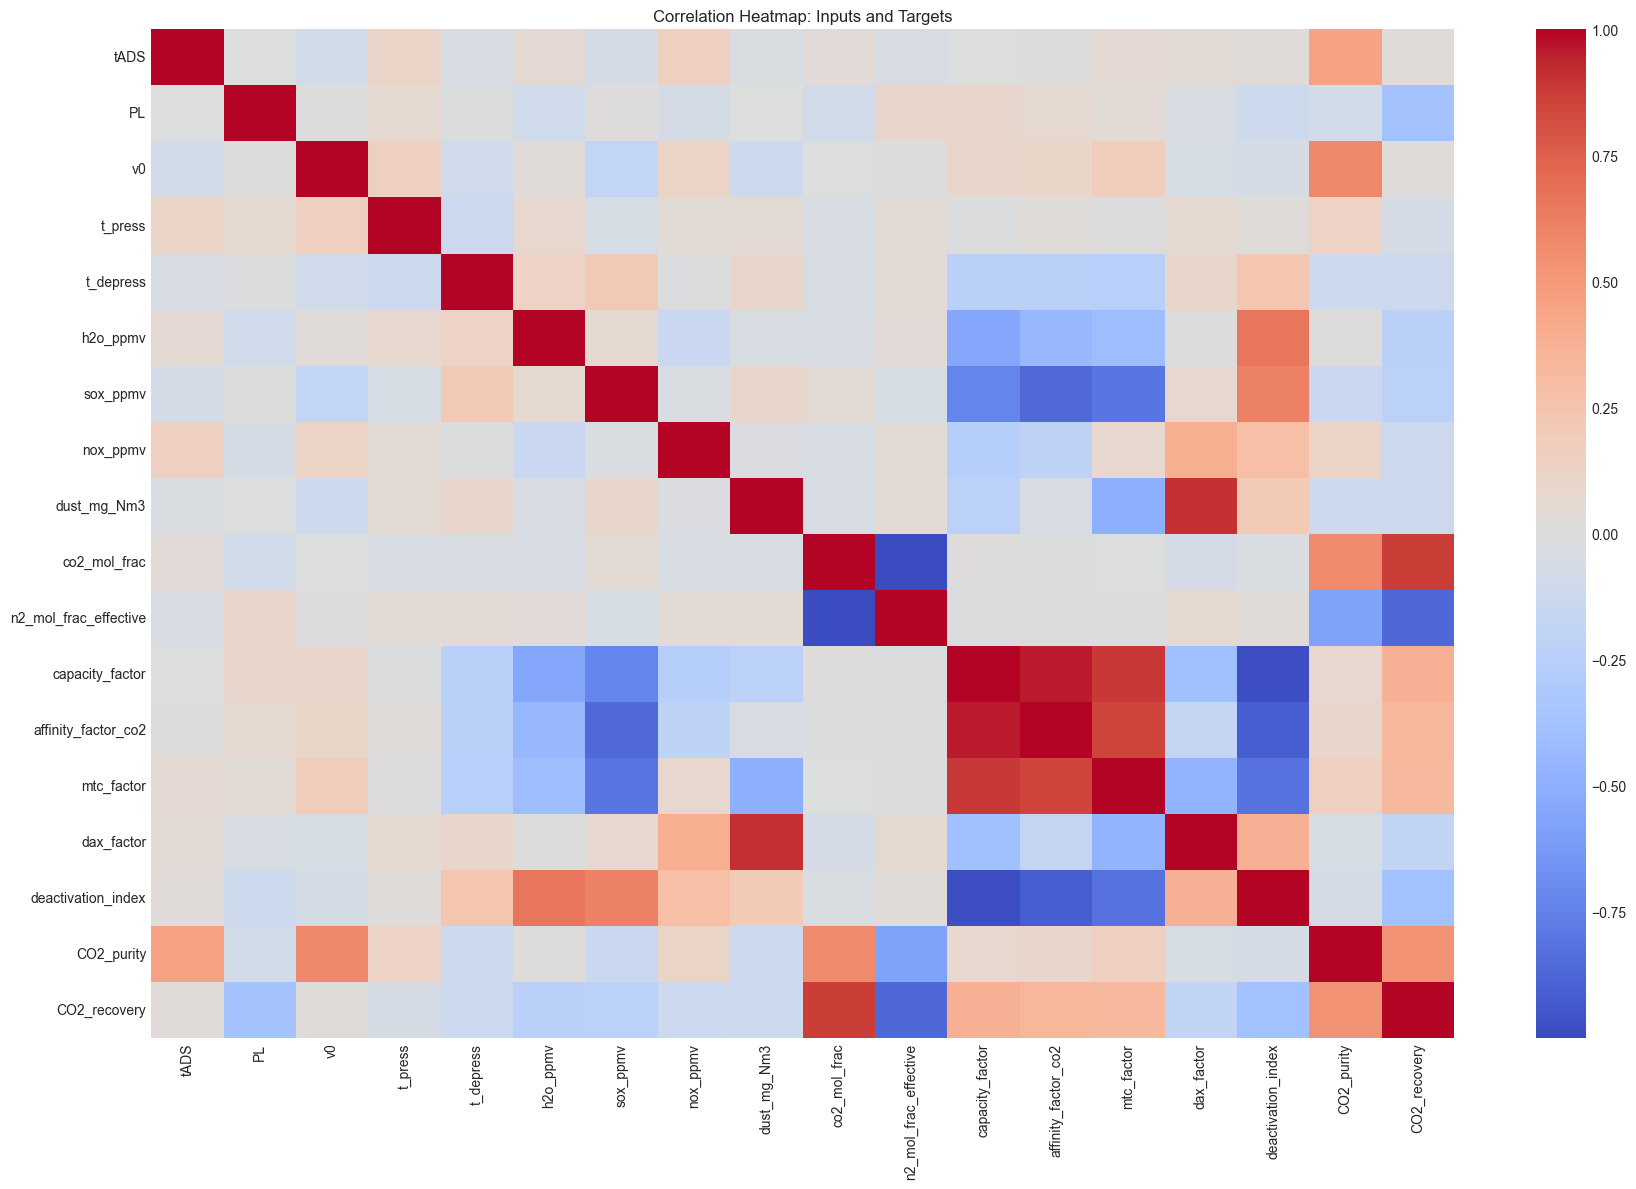

In [12]:
# EDA 1: correlation heatmap for requested inputs and targets
eda_cols = input_cols + target_cols
corr_matrix = df_clean[eda_cols].corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap: Inputs and Targets')
plt.tight_layout()
plt.show()

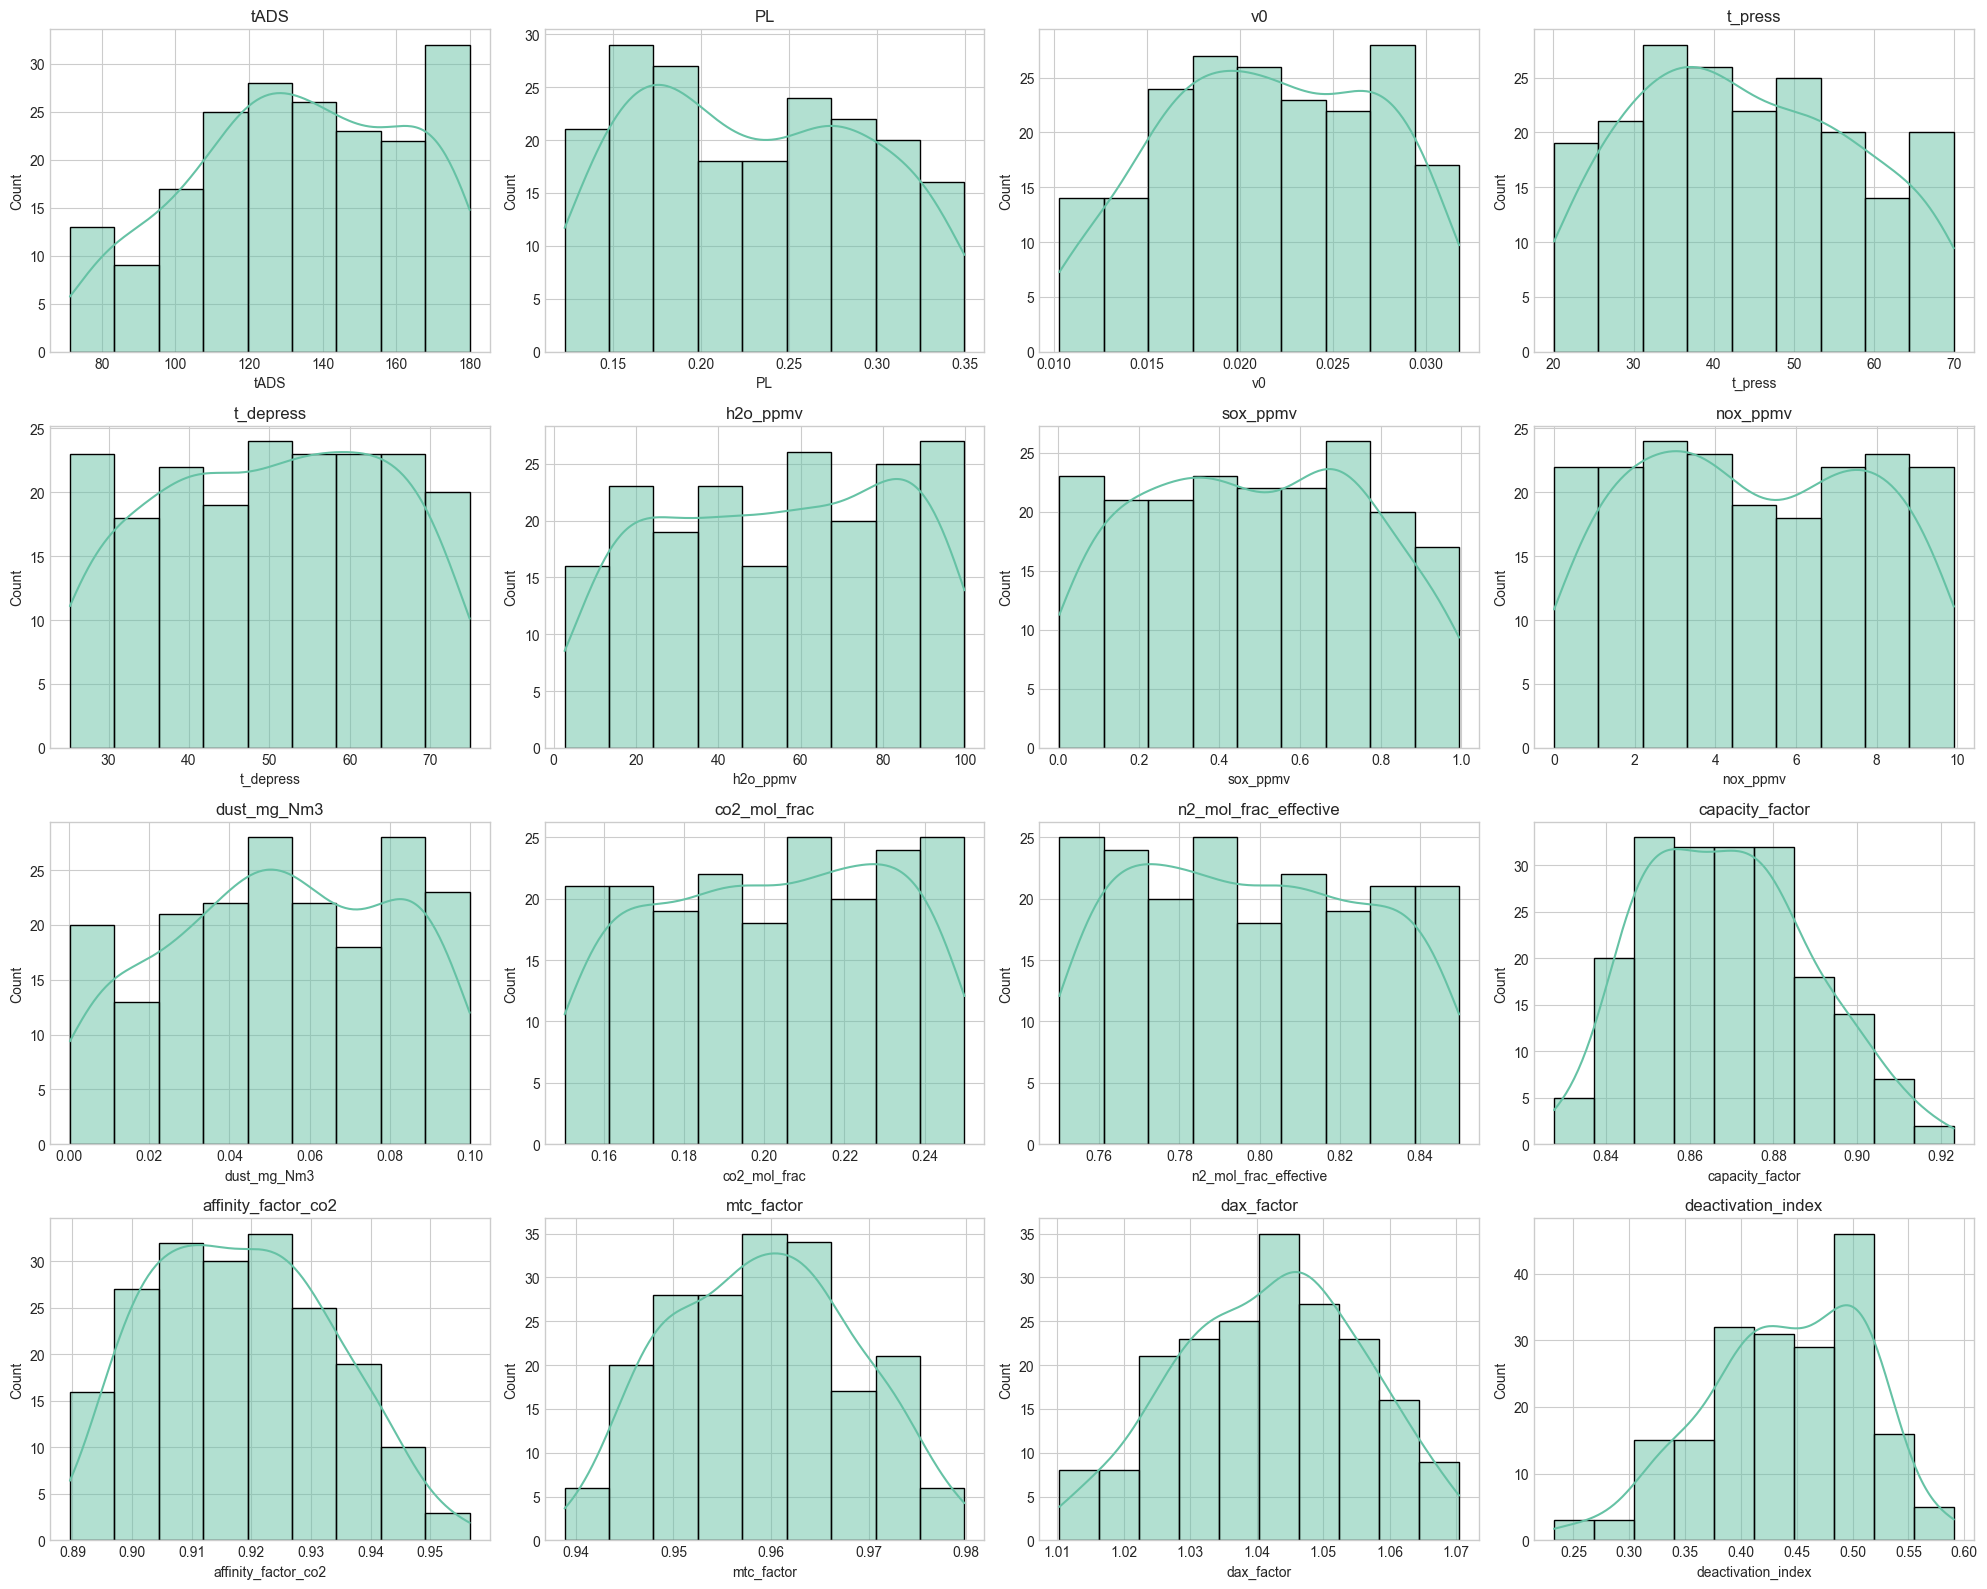

In [13]:
# EDA 2: univariate distributions for all requested inputs
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for ax, col in zip(axes, input_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(col)

for ax in axes[len(input_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

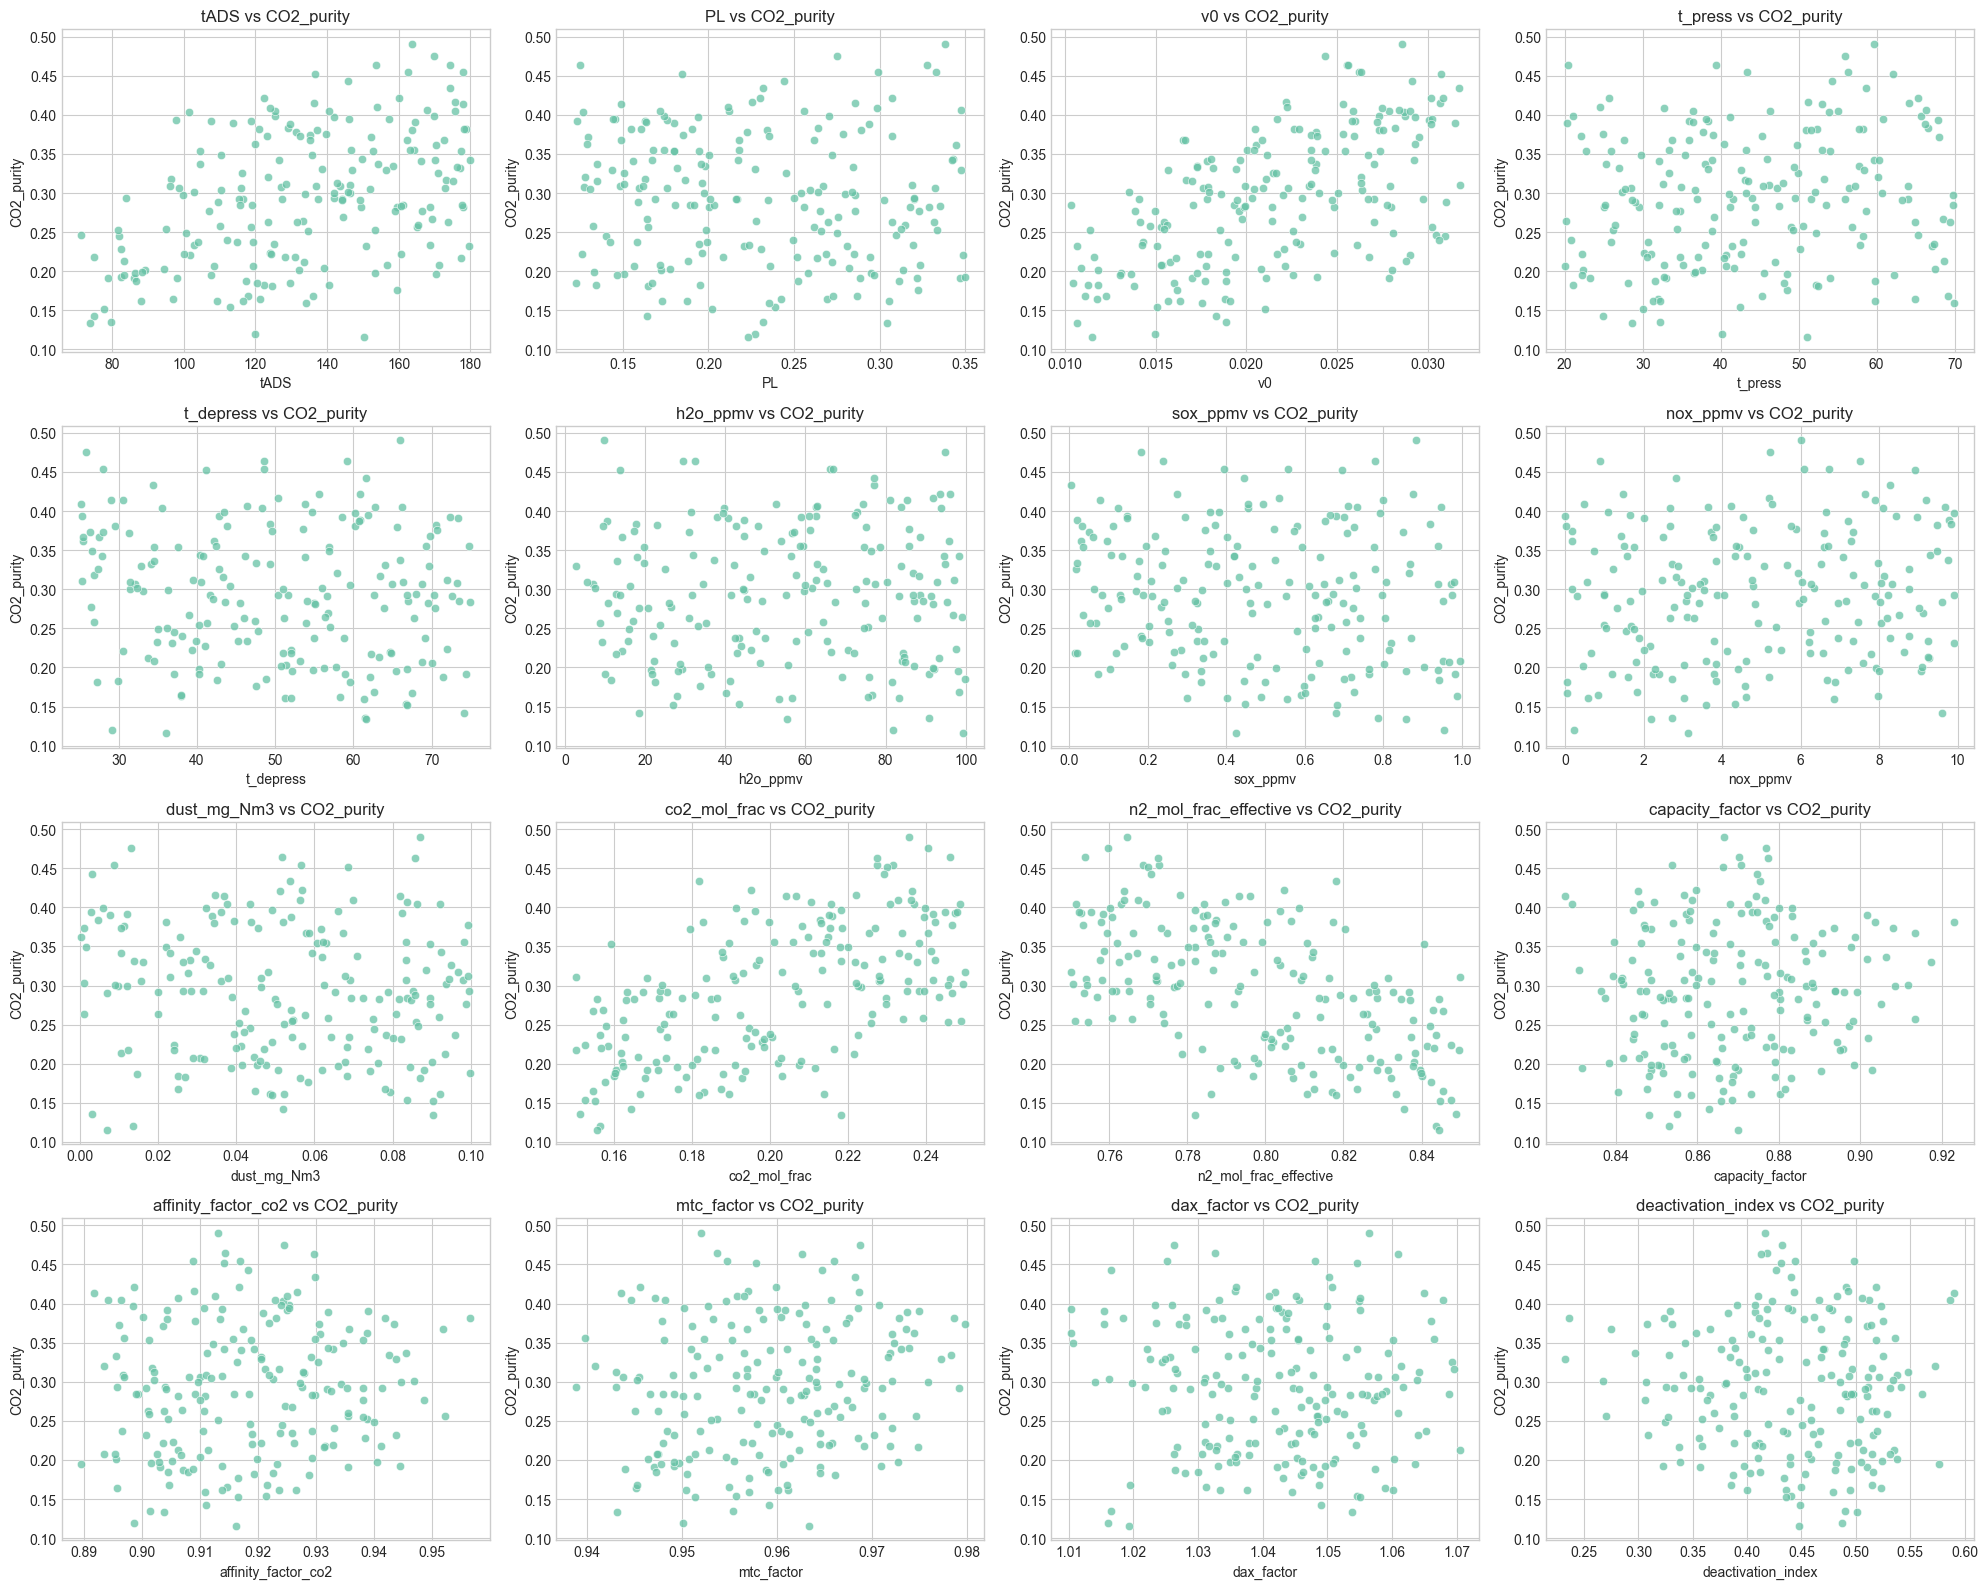

In [14]:
# EDA 3: input vs CO2_purity
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for ax, col in zip(axes, input_cols):
    sns.scatterplot(data=df_clean, x=col, y='CO2_purity', alpha=0.75, ax=ax)
    ax.set_title(f'{col} vs CO2_purity')

for ax in axes[len(input_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

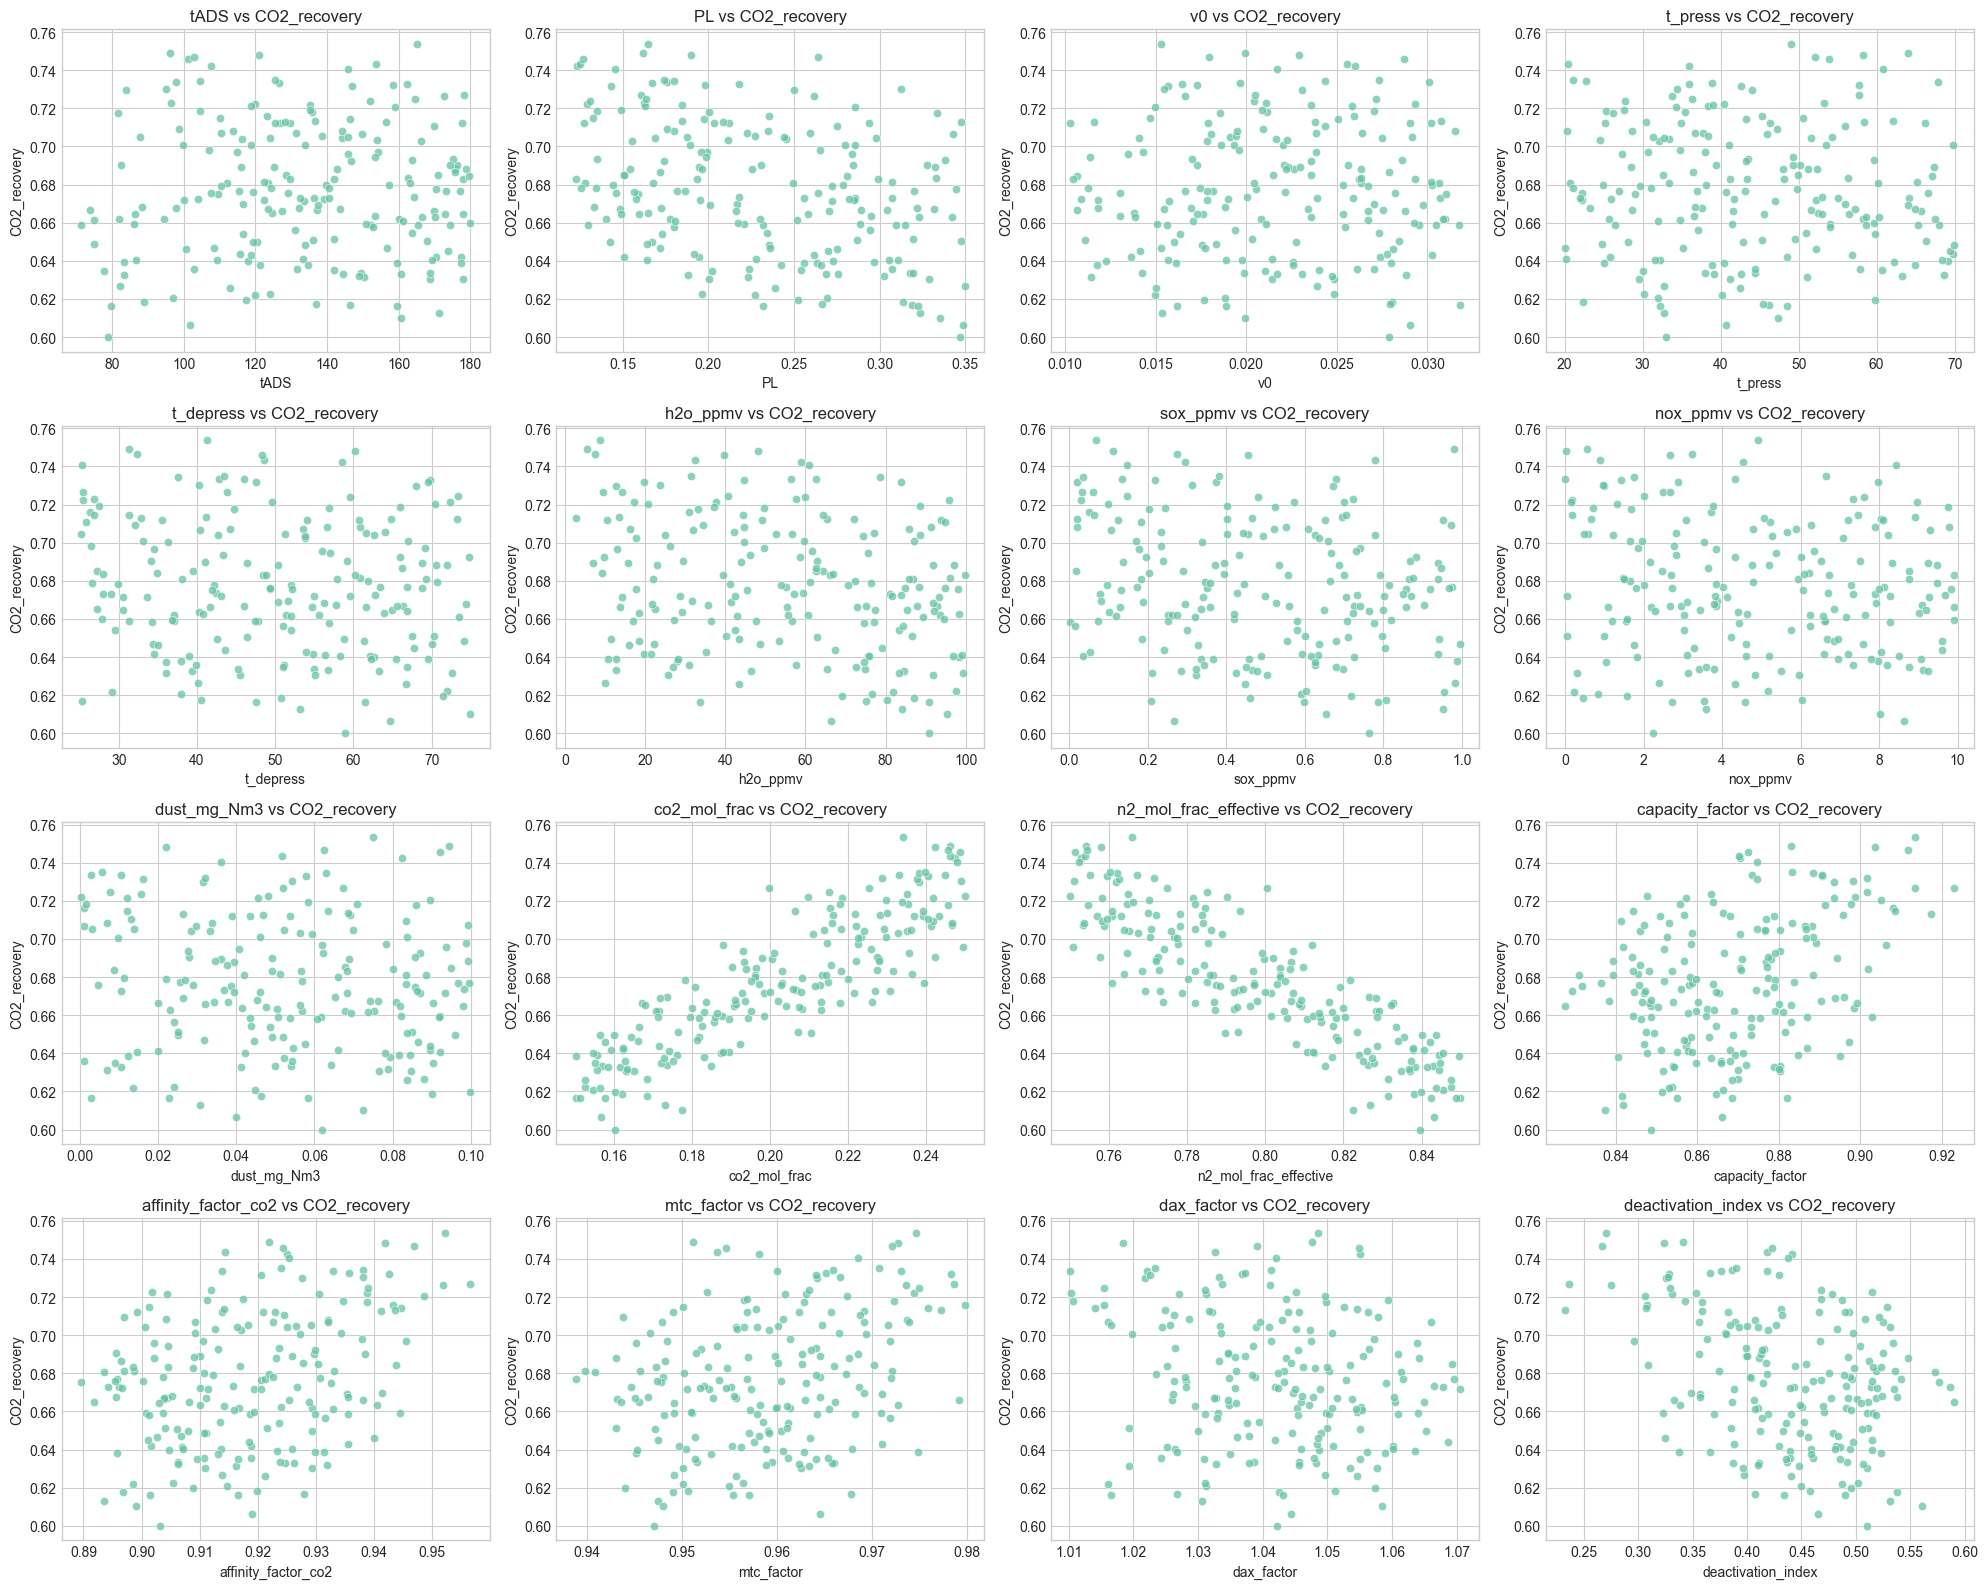

In [15]:
# EDA 4: input vs CO2_recovery
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for ax, col in zip(axes, input_cols):
    sns.scatterplot(data=df_clean, x=col, y='CO2_recovery', alpha=0.75, ax=ax)
    ax.set_title(f'{col} vs CO2_recovery')

for ax in axes[len(input_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

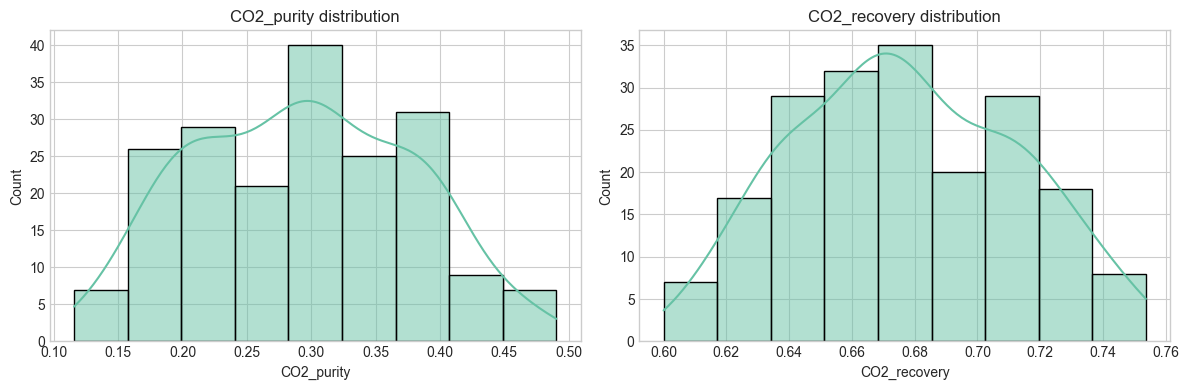

,CO2_purity,CO2_recovery
CO2_purity,1.0000,0.5340
v0,0.5844,0.0207
co2_mol_frac,0.5771,0.8689
CO2_recovery,0.5340,1.0000
tADS,0.4494,0.0254
mtc_factor,0.1587,0.3230
t_press,0.1251,-0.0598
nox_ppmv,0.1123,-0.1285
affinity_factor_co2,0.0894,0.3409
capacity_factor,0.0820,0.3760


In [16]:
# EDA 5: target distributions and ranked correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['CO2_purity'], kde=True, ax=axes[0])
axes[0].set_title('CO2_purity distribution')
sns.histplot(df_clean['CO2_recovery'], kde=True, ax=axes[1])
axes[1].set_title('CO2_recovery distribution')
plt.tight_layout()
plt.show()

rank_table = corr_matrix[['CO2_purity', 'CO2_recovery']].sort_values('CO2_purity', ascending=False)
display(rank_table)

In [17]:
df_clean.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Final output shape: {df_clean.shape}')

Saved: C:\Users\junhyun111\Desktop\mf\model\output.csv
Final output shape: (195, 34)
